In [2]:
from __future__ import print_function  # Mengaktifkan fungsi print versi Python 3

%matplotlib inline                    

import numpy                            # Library untuk perhitungan numerik dan array

import matplotlib.pyplot as plt          # Library untuk membuat grafik/visualisasi

# Review: Finite Differences

Finite Differences adalah metode untuk mendekati turunan suatu fungsi dengan menggunakan nilai fungsi pada beberapa titik yang berdekatan, yang biasanya disebut **stencil**. Metode ini memiliki beberapa variasi seperti jenis titik yang digunakan, tingkat akurasi perhitungan, dan orde turunan yang ingin dihitung. Pada materi ini akan dipelajari cara menurunkan rumus finite differences, menganalisis kesalahan (error), serta melihat contoh penerapannya.

## Derivation of Finite Differences

Secara umum, cara menurunkan rumus **finite differences** biasanya sudah dikenal terutama untuk turunan orde pertama. Misalnya kita ingin menentukan turunan suatu fungsi pada titik \(x_i\). Turunan tersebut dapat didekati dengan tiga cara berbeda, yaitu menggunakan titik di depan, di tengah, atau di belakang dari titik yang ditinjau.

$$
u'(x_i) = \lim_{\Delta x \rightarrow 0} \left \{ \begin{aligned} 
&\frac{u(x_i + \Delta x) - u(x_i)}{\Delta x} & \equiv D_+ u(x_i) \quad \text{(Forward Difference)}\\
&\frac{u(x_i + \Delta x) - u(x_i - \Delta x)}{2 \Delta x} & \equiv D_0 u(x_i) \quad \text{(Central Difference)}\\
&\frac{u(x_i) - u(x_i - \Delta x)}{\Delta x} & \equiv D_- u(x_i) \quad \text{(Backward Difference)}
\end{aligned} \right .
$$

Ketiga rumus tersebut merupakan pendekatan untuk menghitung turunan dengan menggunakan nilai fungsi di titik-titik yang berdekatan. Cara ini disebut **finite difference**, yang banyak digunakan dalam perhitungan numerik dan simulasi komputer.

Jika $\Delta x$ tidak dibuat mendekati nol, maka kita dapat menggunakan nilai tersebut untuk **mendekati turunan** $u'(x_i)$. Artinya, rumus turunan yang digunakan sebenarnya adalah **aproksimasi turunan** ketika $\Delta x$ kecil tetapi tidak nol.

Selanjutnya, kita akan mempelajari cara yang lebih sistematis untuk membuat pendekatan ini, termasuk meningkatkan **akurasi**, menghitung **turunan orde lebih tinggi**, dan memahami **error** dari pendekatan tersebut.

### Interpolating Polynomials

Salah satu cara untuk mendapatkan rumus **finite difference** adalah dengan membuat **polinom interpolasi** dari beberapa titik data (stencil), kemudian menurunkannya.  

Misalkan terdapat $N+1$ titik data  
$(x_0,u(x_0)), (x_1,u(x_1)), \ldots, (x_N,u(x_N))$  
dengan semua $x_i$ berbeda. Polinom interpolasi $P_N(x)$ dapat ditulis sebagai

$$
P_N(x) = \sum^{N}_{i=0} u(x_i) \ell_i(x)
$$

di mana fungsi basis $\ell_i(x)$ didefinisikan sebagai

$$
\ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j}
$$

Fungsi ini digunakan untuk membentuk polinom yang **melewati semua titik data yang diberikan**.

Perhatikan bahwa $\ell_i(x_i) = 1$ dan untuk semua $j \neq i$, berlaku $\ell_i(x_j) = 0$.

Artinya, fungsi $\ell_i(x)$ bernilai **1 pada titiknya sendiri** dan **0 pada titik lainnya**.  

Karena kita sudah mengetahui cara menurunkan sebuah **polinom**, maka kita dapat menghitung **aproksimasi turunan (finite difference)** dari titik-titik data tersebut.

#### Example: 2-Point Stencil

Misalkan kita memiliki **dua titik** untuk mendekati turunan suatu fungsi.  
Polinom interpolasi yang melalui dua titik tersebut berbentuk **fungsi linear**, yaitu

$$
P_1(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} + u(x_1) \frac{x - x_0}{x_1 - x_0}.
$$

Polinom ini dibentuk agar **melewati kedua titik data** yang diberikan.  
Selanjutnya, turunkan polinom tersebut untuk mendapatkan **pendekatan turunan di titik $x_0$**.

Jika polinom $P_1(x)$ diturunkan terhadap $x$, maka diperoleh

$$
P'_1(x) = u(x_0) \frac{1}{x_0 - x_1} + u(x_1) \frac{1}{x_1 - x_0}.
$$

Hasil ini menunjukkan bentuk **pendekatan turunan** yang diperoleh dari polinom interpolasi dua titik.

Jika jarak antara $x_0$ dan $x_1$ dituliskan sebagai $\Delta x = x_1 - x_0$, maka persamaan sebelumnya dapat ditulis menjadi

$$
P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}
$$

Bentuk ini merupakan **rumus pendekatan turunan** yang sama dengan metode **forward difference** ($D_+u(x)$) atau **backward difference** ($D_-u(x)$).

Jika jumlah titik diperluas menjadi **tiga titik**, maka polinom interpolasi yang terbentuk adalah **polinom orde dua (kuadratik)**, yaitu

$$
P_2(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2}
+ u(x_1) \frac{x - x_0}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2}
+ u(x_2) \frac{x - x_0}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1}.
$$

Polinom ini digunakan untuk **menghubungkan tiga titik data**, sehingga dapat dipakai untuk mendapatkan pendekatan turunan yang lebih akurat.

Jika polinom $P_2(x)$ diturunkan terhadap $x$, maka diperoleh

$$
\begin{aligned}
P'_2(x) &= u(x_0) \left( \frac{1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + \frac{x - x_1}{x_0 - x_1} \frac{1}{x_0 - x_2}\right ) \\
&+ u(x_1) \left ( \frac{1}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + \frac{x - x_0}{x_1 - x_0} \frac{1}{x_1 - x_2} \right ) \\
&+ u(x_2)\left ( \frac{1}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1} + \frac{x - x_0}{x_2 - x_0} \frac{1}{x_2 - x_1} \right )
\end{aligned}
$$

Setelah disederhanakan dengan jarak antar titik $\Delta x$, persamaan ini dapat ditulis menjadi

$$
\begin{aligned}
P'_2(x) &=\frac{u(x_0)}{2\Delta x^2} (2x - x_2 - x_1) 
+ \frac{u(x_1)}{-\Delta x^2} (2x - x_2 - x_0) \\
&+ \frac{u(x_2)}{2\Delta x^2}(2x - x_1 - x_0).
\end{aligned}
$$

Hasil ini menunjukkan bentuk **turunan dari polinom interpolasi tiga titik**, yang nantinya digunakan untuk mendapatkan **pendekatan turunan dengan akurasi lebih baik**.

Jika turunan tersebut dihitung pada titik tengah $x_1$, maka diperoleh

$$
\begin{aligned}
P'_2(x_1) &= \frac{u(x_0)}{2\Delta x^2} (x_1 - x_2)
+ \frac{u(x_1)}{-\Delta x^2} (x_1 - x_2 + x_1 - x_0)
+ \frac{u(x_2)}{\Delta x^2} (x_1 - x_0) \\
&= \frac{u(x_2) - u(x_0)}{2 \Delta x}
\end{aligned}
$$

Hasil ini merupakan **rumus pendekatan turunan menggunakan tiga titik**, yang dikenal sebagai **central difference**.

### Taylor-Series Methods

Cara lain untuk menurunkan rumus **finite difference** adalah dengan menggunakan **deret Taylor** dan metode **koefisien tak diketahui**.

Deret Taylor menyatakan bahwa suatu fungsi dapat ditulis sebagai penjumlahan turunan-turunannya di sekitar suatu titik $x_n$.

$$
u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)
$$

Persamaan ini digunakan untuk membuat **pendekatan turunan fungsi** dalam metode finite difference.

Misalkan kita ingin menurunkan **pendekatan turunan pertama dengan akurasi orde dua**. Untuk itu digunakan dua titik di sekitar $x_n$, yaitu $(x_{n+1}, u(x_{n+1}))$ dan $(x_{n-1}, u(x_{n-1}))$.

Nilai $u(x_{n+1})$ dapat dituliskan menggunakan **deret Taylor** sebagai berikut

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n) + (x_{n+1} - x_n) u'(x_n) 
+ \frac{(x_{n+1} - x_n)^2}{2!} u''(x_n) \\
&+ \frac{(x_{n+1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n+1} - x_n)^4) \\
&= u(x_n) + \Delta x\, u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) 
+ \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

Nilai $u(x_{n-1})$ juga dapat dituliskan menggunakan **deret Taylor** di sekitar titik $x_n$ sebagai berikut

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n) + (x_{n-1} - x_n) u'(x_n) 
+ \frac{(x_{n-1} - x_n)^2}{2!} u''(x_n) \\
&+ \frac{(x_{n-1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n-1} - x_n)^4) \\
&= u(x_n) - \Delta x\, u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) 
- \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

Sekarang untuk mendapatkan rumus pendekatan turunan, kita menggabungkan nilai pada titik-titik tersebut. Misalkan bentuk pendekatannya adalah

$$
u'(x_n) + R(x_n) = A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

di mana $A$, $B$, dan $C$ adalah **koefisien yang akan dicari**, sedangkan $R(x_n)$ menyatakan **error (kesalahan) dari pendekatan**.


Selanjutnya, kita memasukkan (substitusi) bentuk **deret Taylor** ke dalam persamaan pendekatan turunan, sehingga diperoleh

$$
\begin{aligned}
u'(x_n) + R(x_n) &= A \left( u(x_n) + \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) + \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4) \right) \\
&+ B\,u(x_n) \\
&+ C \left( u(x_n) - \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) - \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4) \right)
\end{aligned}
$$

Persamaan ini digunakan untuk **menentukan nilai koefisien** $A$, $B$, dan $C$.

Karena kita ingin error $R(x_n) = \mathcal{O}(\Delta x^2)$, maka semua suku dengan orde lebih rendah harus hilang, kecuali suku yang mengalikan $u'(x_n)$ karena suku tersebut harus bernilai 1 agar menghasilkan pendekatan turunan.

Dengan mengelompokkan suku yang memiliki turunan yang sama $u^{(k)}(x_n)$, kita memperoleh persamaan untuk menentukan koefisien $A$, $B$, dan $C$.

Untuk suku tanpa turunan ($u(x_n)$) diperoleh

$$
\begin{aligned}
u(x_n): & \quad A + B + C = 0 \\
u'(x_n): & \quad A\Delta x - C\Delta x = 1 \\
u''(x_n): & \quad A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2} = 0
\end{aligned}
$$

Persamaan ini kemudian digunakan untuk mencari nilai **$A$, $B$, dan $C$**.

Dari persamaan terakhir diperoleh $A = -C$. Jika dimasukkan ke persamaan kedua, maka didapat

$$
A = \frac{1}{2\Delta x}, \quad C = -\frac{1}{2\Delta x}
$$

Kemudian dari persamaan pertama diperoleh

$$
B = 0
$$

Dengan memasukkan nilai $A$, $B$, dan $C$, maka diperoleh pendekatan turunan

$$
u'(x_n) + R(x_n) = \frac{u(x_{n+1}) - u(x_{n-1})}{2\Delta x} + \text{suku error}
$$

Error dari pendekatan ini adalah

$$
R(x_n) = \frac{\Delta x^2}{3!} u'''(x_n) + \mathcal{O}(\Delta x^3)
$$

Artinya, metode ini memiliki **error orde $\mathcal{O}(\Delta x^2)$**, sehingga disebut **pendekatan orde dua (second-order accuracy)**.

### Example: First Order Derivatives

Contoh berikut menunjukkan cara menghitung **turunan orde pertama** menggunakan metode **finite difference**.

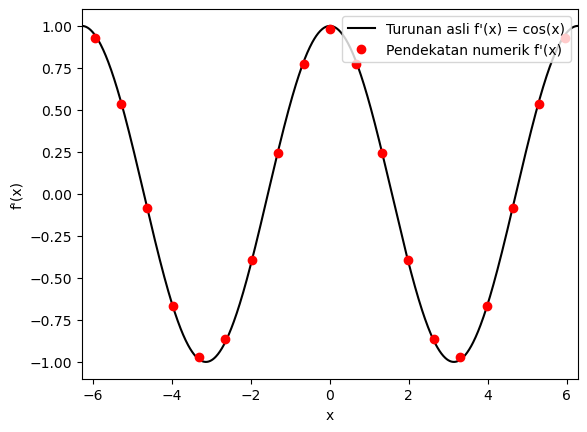

In [6]:
f = lambda x: numpy.sin(x)          # fungsi f(x) = sin(x)
f_prime = lambda x: numpy.cos(x)    # turunan asli f'(x) = cos(x)

# Gunakan diskretisasi seragam
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)   # titik x banyak untuk grafik halus
N = 20                                                  # jumlah titik diskrit
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # titik diskrit untuk metode numerik
delta_x = x_hat[1] - x_hat[0]                           # jarak antar titik (Δx)

# Menghitung turunan dengan forward difference
f_prime_hat = numpy.empty(x_hat.shape)  # array untuk menyimpan hasil turunan numerik
for i in range(N - 1):                  # perulangan menghitung turunan di setiap titik
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x  # rumus forward difference

# Menggunakan backward difference pada titik terakhir
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x  # turunan di titik paling ujung

fig = plt.figure()                # membuat area gambar (figure)
axes = fig.add_subplot(1, 1, 1)   # membuat satu subplot / satu grafik

axes.plot(x, f_prime(x), 'k', label="Turunan asli f'(x) = cos(x)")  # garis hitam = turunan analitik
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'ro', label="Pendekatan numerik f'(x)")  # titik merah = hasil metode numerik

axes.set_xlim((x[0], x[-1]))   # menentukan batas sumbu x
axes.set_ylim((-1.1, 1.1))     # menentukan batas sumbu y
axes.set_xlabel("x")           # memberi label sumbu x
axes.set_ylabel("f'(x)")       # memberi label sumbu y (nilai turunan fungsi)

axes.legend(loc="upper right") # menampilkan legend (keterangan grafik) di sudut kanan atas

plt.show()      # menampilkan grafik